- By Nabankur Ray

# Importing Required Libraries

In [ ]:
""" import subprocess
import sys
import pkg_resources

# List of required packages with versions
requirements = [
    "deap==1.4.1",
]

# Install each package
for pkg in requirements:
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("✅ All packages installed successfully!")

# Verify installed versions
print("\nVerifying installed package versions:")
for pkg in requirements:
    package_name = pkg.split('==')[0]
    try:
        installed_version = pkg_resources.get_distribution(package_name).version
        print(f"{package_name}: {installed_version}")
    except pkg_resources.DistributionNotFound:
        print(f"{package_name}: Not found")"""

Installing deap==1.4.1 ...
✅ All packages installed successfully!

Verifying installed package versions:
deap: 1.4.1


In [ ]:
# Core data manipulation and numerical computing
import pandas as pd              # For handling and analyzing structured/tabular data
import numpy as np               # For numerical computations, arrays, and mathematical operations

# Data preprocessing and feature selection
from sklearn.preprocessing import StandardScaler      # Standardizes features by removing the mean and scaling to unit variance
from sklearn.feature_selection import VarianceThreshold  # Removes features with low variance (near-constant features)

# Model persistence
import joblib                     # For saving and loading trained machine learning models efficiently

# Model evaluation and validation
from sklearn.model_selection import KFold             # K-Fold cross-validation strategy
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, matthews_corrcoef)  # Evaluation metrics for classification models

# Handling class imbalance and ensemble learning
from imblearn.ensemble import BalancedRandomForestClassifier   # Random Forest classifier that handles imbalanced datasets

# Hyperparameter optimization
from hyperopt import hp, fmin, tpe, Trials          # Hyperparameter search space, optimization function, and trial tracking
from hyperopt.early_stop import no_progress_loss    # Early stopping criterion for optimization runs

# Cross-validation scoring
from sklearn.model_selection import cross_validate, cross_val_score   # Functions for cross-validation and scoring

# Evolutionary algorithms (Genetic Algorithm optimization)
from deap import base, creator, tools, algorithms   # Framework for building evolutionary algorithms and genetic optimization

# Custom scoring functions
from sklearn.metrics import make_scorer             # To define custom scoring metrics (e.g., MCC as a scorer)

# Random number generation
import random                                       # For reproducibility and stochastic processes in optimization


In [ ]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Loading the Datasets

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the CSV Files
path = "/content/drive/My Drive/"

# Load DIA_testset_RDKit_descriptors (assumed .csv)
test_df = pd.read_csv(path + "DIA_testset_RDKit_descriptors.csv")

# Load DIA_trainingset_RDKit_descriptors (assumed .csv)
train_df = pd.read_csv(path + "DIA_trainingset_RDKit_descriptors.csv")

# Load RDKit_ChemDes Excel File
excel_df = pd.read_excel(path + "RDKit_ChemDes.xlsx")

# Display the first few rows of each DataFrame
print("Test Set:")
print(test_df.head())

print("\nTraining Set:")
print(train_df.head())

print("\nExcel Data:")
print(excel_df.head())

Mounted at /content/drive
Test Set:
   Label                                             SMILES  BalabanJ  \
0      0  C[C@H](\C=C\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\C(=...     1.484   
1      1     OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1     1.472   
2      0  C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H]...     0.837   
3      1                    NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N     2.406   
4      0  COc1cc2c(CCN[C@]23CS[C@@H]4[C@@H]5[C@@H]6N(C)[...     1.320   

    BertzCT    Chi0   Chi0n   Chi0v    Chi1   Chi1n   Chi1v  ...  fr_sulfide  \
0   743.207  21.466  18.764  18.764  14.292  12.106  12.106  ...           0   
1   868.947  21.140  16.736  17.553  14.453  10.268  11.084  ...           0   
2  1409.004  39.189  32.904  32.904  26.011  20.941  20.941  ...           0   
3   621.298  13.828  10.297  10.297   9.092   5.847   5.847  ...           0   
4  2127.996  37.955  30.849  31.666  25.910  18.066  19.115  ...           1   

   fr_sulfonamd  fr_sulfone  fr_term_acetyle

In [ ]:
test_df.head()

,Label,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,C[C@H](\C=C\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\C(=...,1.484,743.207,21.466,18.764,18.764,14.292,12.106,12.106,...,0,0,0,0,0,0,0,0,0,0
1,1,OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1,1.472,868.947,21.140,16.736,17.553,14.453,10.268,11.084,...,0,0,0,0,0,0,0,0,0,0
2,0,C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H]...,0.837,1409.004,39.189,32.904,32.904,26.011,20.941,20.941,...,0,0,0,0,0,0,0,0,0,0
3,1,NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N,2.406,621.298,13.828,10.297,10.297,9.092,5.847,5.847,...,0,0,0,0,0,0,0,0,0,0
4,0,COc1cc2c(CCN[C@]23CS[C@@H]4[C@@H]5[C@@H]6N(C)[...,1.320,2127.996,37.955,30.849,31.666,25.910,18.066,19.115,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
train_df.head()

,Label,SMILES,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,COC(=O)N(C)c1c(N)nc(nc1N)c2nn(Cc3ccccc3F)c4ncc...,1.821,1266.407,22.121,16.781,16.781,14.901,9.203,9.203,...,0,0,0,0,0,0,0,0,0,0
1,0,C[C@H](N(O)C(=O)N)c1cc2ccccc2s1,2.363,490.434,11.707,8.752,9.569,7.592,4.854,5.670,...,0,0,0,0,0,0,0,1,0,1
2,0,C[N+](C)(C)CC(=O)[O-],3.551,93.092,6.784,5.471,5.471,3.417,2.420,2.420,...,0,0,0,0,0,0,0,0,0,0
3,1,CC(C)n1c(\C=C\[C@H](O)C[C@H](O)CC(=O)O)c(c2ccc...,2.076,1053.003,21.836,16.995,16.995,14.274,9.926,9.926,...,0,0,0,0,0,0,0,0,0,0
4,1,C\C(=C(\C#N)/C(=O)Nc1ccc(cc1)C(F)(F)F)\O,2.888,549.823,14.629,9.746,9.746,8.752,5.040,5.040,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
excel_df.head()

,Index,Descriptor Name,Type,Description,Dimention,Extended class
0,1,BalabanJ,Balaban's J index,"Balaban's J value for a molecule,Chem. Phys. L...",2,Topological descriptors
1,2,BertzCT,BertzCT,"A topological index meant to quantify ""complex...",2,Topological descriptors
2,3,Chi0,Chi indices,"From equations (1),(9) and (10) of Rev. Comp. ...",2,Connectivity descriptors
3,4,Chi1,Chi indices,"From equations (1),(11) and (12) of Rev. Comp....",2,Connectivity descriptors
4,5,Chi0v,Chi indices,"From equations (5),(9) and (10) of Rev. Comp. ...",2,Connectivity descriptors


# Data Understanding

In [ ]:
# Count training set
train_total = len(train_df)
train_pos = train_df["Label"].sum()
train_neg = train_total - train_pos

# Count external validation set (test set)
test_total = len(test_df)
test_pos = test_df["Label"].sum()
test_neg = test_total - test_pos

# Total
total_samples = train_total + test_total
total_pos = train_pos + test_pos
total_neg = train_neg + test_neg

# Build table in the same format as paper
table1 = pd.DataFrame({
    "Datasets": ["Training set", "External validation set", "Total"],
    "DIA-positive drugs": [train_pos, test_pos, total_pos],
    "DIA-negative drugs": [train_neg, test_neg, total_neg],
    "Total": [train_total, test_total, total_samples]
})

# Display
print(table1.to_string(index=False))

               Datasets  DIA-positive drugs  DIA-negative drugs  Total
           Training set                 118                 359    477
External validation set                  30                  90    120
                  Total                 148                 449    597


In [ ]:
X_train = train_df.iloc[:, 2:]
Y_train = train_df.iloc[:, 0]

In [ ]:
X_test = test_df.iloc[:, 2:]
Y_test = test_df.iloc[:, 0]

# Task - 1

## Data Preprocessing

**Feature preprocessing pipeline**

**Z-score normalization** - All descriptors were standardized to have zero mean and unit variance, ensuring comparability across features.

**Low-variance filtering** - Descriptors with little to no variance were removed, as they provided limited discriminative information.

**Correlation pruning** - Features with a Pearson correlation coefficient above 0.9 were eliminated to avoid multicollinearity.

In [ ]:
# Feature preprocessing pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import joblib

def preprocess_features(X_train, X_test):
    """
    Preprocess features: standardization, variance threshold, correlation filtering

    Args:
        X_train (pd.DataFrame): Training features
        X_test (pd.DataFrame): Test features

    Returns:
        X_train_processed, X_test_processed (pd.DataFrame)
    """
    # 2.1. Check missing values
    print("\nMissing values:")
    print("Training set:", X_train.isnull().sum().sum())
    print("Test set:", X_test.isnull().sum().sum())

    # 2.2. Standardization
    scaler = StandardScaler()
    X_train_std = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_std = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )
    joblib.dump(scaler, 'scaler.pkl')  # Save the scaler for reproducibility

    # 2.3. Remove zero-variance features
    selector = VarianceThreshold()
    selector.fit(X_train_std)
    keep_vars = X_train.columns[selector.variances_ != 0].tolist()

    X_train_var = X_train_std[keep_vars]
    X_test_var = X_test_std[keep_vars]

    # 2.4. Remove highly correlated features
    corr_matrix = X_train_var.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_features = [column for column in upper.columns if any(upper[column] > 0.9)]

    X_train_processed = X_train_var.drop(columns=drop_features)
    X_test_processed = X_test_var.drop(columns=drop_features)

    print(f"\nFeatures reduced from {X_train.shape[1]} to {X_train_processed.shape[1]}")

    # Save processed features
    X_train_processed.to_csv("X_train_processed2.csv", index=False)
    X_test_processed.to_csv("X_test_processed2.csv", index=False)

    return X_train_processed, X_test_processed


In [ ]:
# Preprocess features
X_train_processed, X_test_processed = preprocess_features(Xtrain, Xtest)


Missing values:
Training set: 0
Test set: 0

Features reduced from 196 to 140


In [ ]:
X_train_processed

,BalabanJ,BertzCT,Chi0,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,-0.452875,1.344465,0.551264,-0.525136,-0.384981,-0.181361,1.395076,0.554831,-0.812459,0.507059,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
1,0.310322,-0.632257,-0.887194,-0.263887,-0.305248,-0.181361,-1.140124,-0.755872,-0.247407,-0.915263,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,5.551415,-0.238492,5.974304
2,1.983159,-1.644450,-1.567194,-0.530553,-0.315105,-0.181361,-0.672837,-0.799998,-1.087602,-0.915263,...,6.833740,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
3,-0.093806,0.800838,0.511898,0.283293,0.611727,-0.181361,0.164995,-1.141063,0.469142,-0.061968,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
4,1.049581,-0.480968,-0.483586,0.474686,0.471975,-0.181361,-0.734095,-1.141063,0.663707,-0.488440,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,-0.169844,-0.511260,-1.013166,-0.791321,-1.281364,-0.181361,-1.140124,-1.141063,0.335614,0.233622,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
473,-0.761251,0.280287,-0.032186,-0.043399,0.183298,-0.181361,0.114661,0.273335,1.577292,-0.012105,...,6.833740,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
474,-0.530321,0.436629,0.414242,0.750526,1.088659,-0.181361,1.366018,-1.141063,-0.812459,1.279054,...,-0.146333,3.862468,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384
475,-0.438794,0.477795,0.053591,-0.791321,-1.281364,-0.181361,-0.668410,1.319889,-0.462804,-0.915263,...,-0.146333,-0.222670,-0.204792,-0.122039,-0.079556,-0.09196,-0.168934,-0.155535,-0.238492,-0.167384


**Hyperparameter optimization** is performed for the Balanced Random Forest (BRF) classifier using the preprocessed feature set (X_train_processed) and labels (Y_train).

The **Hyperopt library** with the **Tree-structured Parzen Estimator (TPE)** is employed, with **Matthews Correlation Coefficient (MCC)** as the optimization objective due to its robustness in imbalanced classification problems.

In [ ]:
def get_model_performance(X, y, model_params, random_state=1):
   """Get CV and OOF performance metrics for a model"""
   model = BalancedRandomForestClassifier(**model_params)
   cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
   cv_metrics = []

   # Get CV metrics
   for train_idx, val_idx in cv.split(X):
       X_train_fold = X.iloc[train_idx]
       X_val_fold = X.iloc[val_idx]
       y_train_fold = y.iloc[train_idx]
       y_val_fold = y.iloc[val_idx]

       model.fit(X_train_fold, y_train_fold)
       y_pred = model.predict(X_val_fold)
       y_pred_proba = model.predict_proba(X_val_fold)[:, 1]

       tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()
       metrics = {
           'AUC': roc_auc_score(y_val_fold, y_pred_proba),
           'ACC': accuracy_score(y_val_fold, y_pred),
           'SEN': tp / (tp + fn),
           'SPE': tn / (tn + fp),
           'MCC': matthews_corrcoef(y_val_fold, y_pred)
       }
       cv_metrics.append(metrics)

   cv_mean = {m: np.mean([fold[m] for fold in cv_metrics]) for m in cv_metrics[0].keys()}

   # Get OOF predictions
   y_pred_all = np.zeros_like(y)
   y_pred_proba_all = np.zeros_like(y, dtype=float)

   for train_idx, val_idx in cv.split(X):
       X_train_fold = X.iloc[train_idx]
       X_val_fold = X.iloc[val_idx]
       y_train_fold = y.iloc[train_idx]

       model.fit(X_train_fold, y_train_fold)
       y_pred_all[val_idx] = model.predict(X_val_fold)
       y_pred_proba_all[val_idx] = model.predict_proba(X_val_fold)[:, 1]

   # Calculate OOF metrics
   tn, fp, fn, tp = confusion_matrix(y, y_pred_all).ravel()
   oof_metrics = {
       'AUC': roc_auc_score(y, y_pred_proba_all),
       'ACC': accuracy_score(y, y_pred_all),
       'SEN': tp / (tp + fn),
       'SPE': tn / (tn + fp),
       'MCC': matthews_corrcoef(y, y_pred_all)
   }

   # Create results table
   metrics_order = ['AUC', 'ACC', 'SEN', 'SPE', 'MCC']
   results = pd.DataFrame({
       'Metric': metrics_order,
       'CV Mean': [cv_mean[m] for m in metrics_order],
       'Out-of-fold': [oof_metrics[m] for m in metrics_order]
   })

   return results

def optimize_brf(X, y, random_state=1):
    def objective(params):
        model = BalancedRandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            criterion=params["criterion"],
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            sampling_strategy='auto',
            replacement=False,
            random_state=random_state,
            n_jobs=-1
        )
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(
            model, X, y,
            cv=cv,
            scoring="matthews_corrcoef",
            n_jobs=-1,
            error_score="raise"
        )
        return -np.mean(scores["test_score"])

    max_features_choices = ["sqrt", "log2"] + list(range(10, 70))
    param_space = {
        'n_estimators': hp.quniform("n_estimators", 40, 300, 1),
        'criterion': hp.choice("criterion", ["gini", "entropy"]),
        'max_depth': hp.quniform('max_depth', 1, 25, 1),
        'max_features': hp.choice("max_features", max_features_choices)
    }

    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=param_space,
        algo=tpe.suggest,
        max_evals=10,
        trials=trials,
        early_stop_fn=no_progress_loss(400),
        verbose=True
    )

    # Convert parameters to correct types
    best_params = {
        "n_estimators": int(best_params["n_estimators"]),
        "criterion": ["gini", "entropy"][best_params["criterion"]],
        "max_depth": int(best_params["max_depth"]),
        "max_features": max_features_choices[best_params["max_features"]],
        "bootstrap": True,
        "sampling_strategy": 'auto',
        "replacement": False,
        "random_state": random_state,
        "verbose": False,
        "n_jobs": -1
    }

    return best_params

In [ ]:
# Define best parameters for feature processing
best_params = {
   'n_estimators': 255,
   'criterion': 'gini',
   'max_depth': 16,
   'max_features': 30,
   'bootstrap': True,
   'sampling_strategy': 'auto',
   'replacement': False,
   'random_state': 1,
   'verbose': False,
   'n_jobs': -1
}
# Get model performance
results = get_model_performance(X_train_processed, Ytrain, best_params)
print("\nModel Performance:")
print(results.to_string(index=False, float_format='%.4f'))


Model Performance:
Metric  CV Mean  Out-of-fold
   AUC   0.8545       0.8617
   ACC   0.7820       0.7820
   SEN   0.7740       0.7881
   SPE   0.7806       0.7799
   MCC   0.5022       0.5105


Once the optimal hyperparameters are identified, the BRF model is retrained with these settings and used for subsequent feature selection. This ensures that the feature selection process is guided by a well-calibrated, performance-optimized model.

In [ ]:
# best model from preprocessing
best_model_preprocessing = BalancedRandomForestClassifier(
   n_estimators=255,
   criterion='gini',
   max_depth=16,
   max_features=30,
   bootstrap=True,
   sampling_strategy='auto',
   replacement=False,
   random_state=1,
   verbose=False,
   n_jobs=-1
)
best_model_preprocessing.fit(X_train_processed,Ytrain)

BalancedRandomForestClassifier(bootstrap=True, max_depth=16, max_features=30,
                               n_estimators=255, n_jobs=-1, random_state=1,
                               replacement=False, sampling_strategy='auto',
                               verbose=False)

## Feature Selection

**RDKit_GA_65**

* Started with 196 descriptors computed using the RDKit toolkit.

* Applied preprocessing steps such as z-score normalization, removal of low-variance descriptors, and correlation pruning (ρ > 0.9).

* A Genetic Algorithm (GA) with a Balanced Random Forest as the fitness evaluator was used for feature selection.

* The GA iteratively optimized descriptor subsets based on the Matthews Correlation Coefficient (MCC), and the final selection contained 65 descriptors.

We are choosing the **Genetic Algorithm (GA)** for feature selection, as this will lead to our desired result for this given task. At the same time, it provides a robust global search mechanism that can capture complex feature interactions and align directly with the optimization metric (MCC)  

In [ ]:
# Genetic Algorithm Feature Selection (GA)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Replace with your actual data
X_train_df = X_train_processed  # Your training feature DataFrame
y_train_df = Ytrain  # Your training label Series

# Save feature names
feature_names = X_train_df.columns

# Convert to numpy arrays
X_train = X_train_df.values
y_train = y_train_df.values

# Define evaluation function
def evaluate(individual):
   selected_features = [index for index, value in enumerate(individual) if value == 1]
   if not selected_features:
       return -1,  # Return -1 score if no features selected (worst case)
   X_train_selected = X_train[:, selected_features]
   clf = BalancedRandomForestClassifier(
       n_estimators=255,
       criterion="gini",
       max_depth=16,
       max_features=30,
       bootstrap=True,
       sampling_strategy='auto',
       replacement=False,
       random_state=1,
       verbose=False,
       n_jobs=-1
   )
   mcc_scorer = make_scorer(matthews_corrcoef)
   scores = cross_val_score(clf, X_train_selected, y_train, cv=5, scoring=mcc_scorer)
   return scores.mean(),

# Set GA parameters
NUM_GENES = X_train.shape[1]  # Number of genes equals number of features
POP_SIZE = 50  # Population size
NGEN = 40     # Number of generations
CXPB = 0.5    # Crossover probability
MUTPB = 0.2   # Mutation probability

# Define genetic algorithm type
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", np.random.randint, 2)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=NUM_GENES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# Elite preservation strategy
hof = tools.HallOfFame(1)

# Generate initial population
population = toolbox.population(n=POP_SIZE)

# Run genetic algorithm
result_population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,
                                              stats=None, halloffame=hof, verbose=True)

# Get best individual
best_individual = hof[0]
selected_features = [index for index, value in enumerate(best_individual) if value == 1]

# Print selected feature names
selected_feature_names = feature_names[selected_features]
print(f"Selected features: {selected_feature_names}")
print(f"Best individual MCC on training set: {evaluate(best_individual)[0]}")

# Train and evaluate model with selected features
X_train_selected = X_train[:, selected_features]

gen	nevals
0  	50    
1  	26    
2  	29    
3  	28    
4  	26    
5  	32    
6  	18    
7  	31    
8  	30    
9  	28    
10 	28    
11 	17    
12 	33    
13 	30    
14 	31    
15 	26    
16 	28    
17 	33    
18 	33    
19 	24    
20 	20    
21 	26    
22 	39    
23 	23    
24 	37    
25 	29    
26 	35    
27 	35    
28 	33    
29 	23    
30 	34    
31 	26    
32 	22    
33 	27    
34 	31    
35 	36    
36 	24    
37 	37    
38 	26    
39 	29    
40 	19    
Selected features: Index(['BalabanJ', 'Chi0', 'EState_VSA1', 'EState_VSA10', 'EState_VSA4',
       'EState_VSA6', 'EState_VSA9', 'Ipc', 'NHOHCount',
       'NumAliphaticHeterocycles', 'NumAliphaticRings',
       'NumAromaticCarbocycles', 'NumAromaticRings', 'PEOE_VSA11',
       'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA9',
       'RingCount', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA5', 'SMR_VSA9',
       'SlogP_VSA10', 'SlogP_VSA2', 'SlogP_VSA5', 'SlogP_VSA8', 'VSA_EState10',
       'VSA_EState8', 'VSA_EState9', 'fr_ArN

In [ ]:
# Get selected features for testing set using feature names
X_test_selected = X_test_processed[selected_feature_names]
X_test_selected

,BalabanJ,Chi0,EState_VSA1,EState_VSA10,EState_VSA4,EState_VSA6,EState_VSA9,Ipc,NHOHCount,NumAliphaticHeterocycles,...,fr_nitro_arom,fr_para_hydroxylation,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_pyridine,fr_sulfide,fr_term_acetylene,fr_thiophene,fr_unbrch_alkane
0,-0.927408,0.460791,-0.257990,0.213746,-0.101188,-0.862098,-0.990161,-0.077297,0.376545,-0.810208,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,-0.155535,-0.238492
1,-0.944306,0.415761,-0.278435,0.004021,1.979562,-0.404055,-0.511729,-0.077298,-0.571275,1.348838,...,-0.130605,1.976799,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,-0.155535,-0.238492
2,-1.838457,2.908821,3.180967,2.176713,1.388567,0.642288,2.116130,0.264547,1.798274,3.507883,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,-0.155535,-0.238492
3,0.370871,-0.594226,-0.533262,-0.345554,-1.087602,2.344434,0.084085,-0.077299,0.850454,-0.810208,...,-0.130605,1.976799,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,-0.155535,-0.238492
4,-1.158339,2.738372,1.265508,1.149556,-0.150433,0.054065,1.672361,0.306693,0.850454,6.746451,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,3.862468,-0.079556,-0.155535,-0.238492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,-0.893614,1.136924,1.999232,2.024469,-0.812459,2.996690,-0.990161,-0.077282,-0.097365,2.428360,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,3.862468,-0.079556,-0.155535,-0.238492
116,0.753877,-0.909708,-0.791321,-0.813410,-0.143077,1.054648,-0.497209,-0.077299,-0.571275,-0.810208,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,5.851491,-0.222670,-0.079556,-0.155535,-0.238492
117,-0.665500,-0.382062,-0.791321,-0.782961,0.722049,-0.862098,-0.990161,-0.077299,-0.571275,-0.810208,...,-0.130605,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,5.551415,-0.238492
118,0.648269,0.592840,0.203870,0.641492,-1.087602,1.687195,0.341147,-0.077298,-0.571275,0.269315,...,7.656696,-0.345696,-0.130605,-0.112867,-0.307404,-0.303219,-0.222670,-0.079556,-0.155535,0.490743


## Model Development and Evaluation

The modeling framework included parameter optimization templates for the following classifiers:

* **Balanced Random Forest (BRF)**

* **Easy Ensemble Classifier (EEC)**

* **Balanced Bagging with XGBoost (BBC+XGBoost)**

* **Balanced Bagging with Gradient Boosting (BBC+GBDT)**

* **Balanced Bagging with LightGBM (BBC+LightGBM)**

Model evaluation was conducted using multiple performance strategies, including 10-fold cross-validation, out-of-fold analysis, external test validation, and ROC curve comparisons.

For the purposes of this study, we focus primarily on 10-fold cross-validation results and external test set performance, as these directly align with the desired evaluation objectives.

In [ ]:
def evaluate_model_performance(model, X_train, y_train, X_test, y_test):
   """
   Evaluate model with CV, OOF and test set performance
   """
   def calculate_metrics(y_true, y_pred, y_pred_proba=None):
       tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
       metrics = {
           'ACC': (tp + tn) / (tp + tn + fp + fn),
           'SEN': tp / (tp + fn),
           'SPE': tn / (tn + fp),
           'MCC': matthews_corrcoef(y_true, y_pred)
       }
       if y_pred_proba is not None:
           metrics['AUC'] = roc_auc_score(y_true, y_pred_proba)
       return metrics

   # 10-fold CV evaluation
   cv = KFold(n_splits=10, shuffle=True, random_state=1)
   cv_metrics = []

   # For OOF predictions
   y_pred_all = np.zeros_like(y_train)
   y_pred_proba_all = np.zeros_like(y_train, dtype=float)

   # Get both CV and OOF predictions
   for train_idx, val_idx in cv.split(X_train):
       X_train_fold = X_train.iloc[train_idx]
       X_val_fold = X_train.iloc[val_idx]
       y_train_fold = y_train.iloc[train_idx]
       y_val_fold = y_train.iloc[val_idx]

       # Train model on fold
       model_fold = clone(model)
       model_fold.fit(X_train_fold, y_train_fold)

       # Get predictions for CV metrics
       y_pred = model_fold.predict(X_val_fold)
       y_pred_proba = model_fold.predict_proba(X_val_fold)[:, 1]

       # Store fold metrics
       fold_metrics = calculate_metrics(y_val_fold, y_pred, y_pred_proba)
       cv_metrics.append(fold_metrics)

       # Store OOF predictions
       y_pred_all[val_idx] = y_pred
       y_pred_proba_all[val_idx] = y_pred_proba

   # Calculate mean CV metrics
   cv_mean = {m: np.mean([fold[m] for fold in cv_metrics])
              for m in cv_metrics[0].keys()}

   # Calculate OOF metrics
   oof_metrics = calculate_metrics(y_train, y_pred_all, y_pred_proba_all)

   # Get test set predictions
   model.fit(X_train, y_train)
   y_pred_test = model.predict(X_test)
   y_pred_proba_test = model.predict_proba(X_test)[:, 1]
   test_metrics = calculate_metrics(y_test, y_pred_test, y_pred_proba_test)

   # Create results DataFrame
   metrics_order = ['AUC', 'ACC', 'SEN', 'SPE', 'MCC']
   results = pd.DataFrame({
       'Metric': metrics_order,
       'CV Mean': [cv_mean[m] for m in metrics_order],
       'Out-of-fold': [oof_metrics[m] for m in metrics_order],
       'Test': [test_metrics[m] for m in metrics_order]
   })

   # Get confusion matrix for test set
   tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
   confusion_df = pd.DataFrame(
       {'Confusion_matrix': [tp, fn, fp, tn]},
       index=['TP', 'FN', 'FP', 'TN']
   )

   return results, confusion_df

In [ ]:
# BalancedRandomForestClassifier Optimization


import numpy as np
from sklearn.model_selection import KFold, cross_validate
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss
from imblearn.ensemble import BalancedRandomForestClassifier

def optimize_brf(X, y, random_state=1):
    """
    Optimize BalancedRandomForestClassifier hyperparameters
    """
    def objective(params):
        model = BalancedRandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            criterion=params["criterion"],
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            sampling_strategy='auto',
            replacement=False,
            random_state=random_state,
            n_jobs=-1
        )
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(
            model, X, y,
            cv=cv,
            scoring="matthews_corrcoef",
            n_jobs=-1,
            error_score="raise"
        )
        return -np.mean(scores["test_score"])

    # Define parameter space
    max_features_choices = ["sqrt", "log2"] + list(range(10, 70))
    param_space = {
        'n_estimators': hp.quniform("n_estimators", 40, 300, 1),
        'criterion': hp.choice("criterion", ["gini", "entropy"]),
        'max_depth': hp.quniform('max_depth', 1, 25, 1),
        'max_features': hp.choice("max_features", max_features_choices)
    }

    # Run optimization
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=param_space,
        algo=tpe.suggest,
        max_evals=200,
        trials=trials,
        early_stop_fn=no_progress_loss(400),
        verbose=True
    )

    # Convert parameters to correct types
    best_params = {
        "n_estimators": int(best_params["n_estimators"]),
        "criterion": ["gini", "entropy"][best_params["criterion"]],
        "max_depth": int(best_params["max_depth"]),
        "max_features": max_features_choices[best_params["max_features"]],
        "bootstrap": True,
        "sampling_strategy": 'auto',
        "replacement": False,
        "random_state": random_state,
        "verbose": False,
        "n_jobs": -1
    }

    return best_params

'\n# Optimize BRF parameters\nbest_params_brf = optimize_brf(X_train_selected_df, Ytrain)\nprint("\nBest parameters for BRF:", best_params_brf)\n\n# Initialize and train model with best parameters\nmodel_brf = BalancedRandomForestClassifier(**best_params_brf)\nmodel_brf.fit(X_train_selected_df, Ytrain)\n\n# Evaluate performance\nresults_brf, confusion_matrix_brf = evaluate_model_performance(\n   model_brf, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)\n\nprint("\nBalanced Random Forest Performance:")\nprint(results_brf.to_string(index=False, float_format=\'%.4f\'))\nprint("\nConfusion Matrix:")\nprint(confusion_matrix_brf)\n\n'

In [ ]:
# BalancedRandomForestClassifier

# Using optimized parameters to evaluate model performance

from sklearn.base import clone
from sklearn.model_selection import KFold

# Best model parameters from GA optimization
best_params_ga = {
   'n_estimators': 154,
   'criterion': "gini",
   'max_depth': 15,
   'max_features': 48,
   'sampling_strategy': 'auto',
   'replacement': False,
   'random_state': 1,
   'bootstrap': True,
   'verbose': False,
   'n_jobs': -1
}

# Convert numpy arrays back to DataFrames for selected features
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

# Initialize and train model
model_brf = BalancedRandomForestClassifier(**best_params_ga)
model_brf.fit(X_train_selected_df, Ytrain)

# Evaluate performance
results_brf, confusion_matrix_brf = evaluate_model_performance(
   model_brf, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)

print("\nBalanced Random Forest Performance:")
print(results_brf.to_string(index=False, float_format='%.4f'))
print("\nConfusion Matrix:")
print(confusion_matrix_brf)


Balanced Random Forest Performance:
Metric  CV Mean  Out-of-fold   Test
   AUC   0.8644       0.8687 0.8646
   ACC   0.7986       0.7987 0.7667
   SEN   0.8014       0.8051 0.8333
   SPE   0.7967       0.7967 0.7444
   MCC   0.5418       0.5436 0.5107

Confusion Matrix:
    Confusion_matrix
TP                25
FN                 5
FP                23
TN                67


In [ ]:
# EasyEnsembleClassifier Optimization and Evaluation

from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss
from sklearn.model_selection import KFold, cross_validate
import numpy as np

def optimize_eec(X, y, random_state=1):
   """
   Optimize EasyEnsembleClassifier hyperparameters using hyperopt
   """
   # Define parameter space
   param_space = {
       'n_estimators': hp.quniform('n_estimators', 50, 300, 1),
       'learning_rate': hp.quniform('learning_rate', 0.2, 1.0, 0.1),
       'algorithm': hp.choice('algorithm', ['SAMME', 'SAMME.R']),
       'base_estimator_max_depth': hp.quniform('base_estimator_max_depth', 1, 10, 1)
   }

   def objective(params):
       base_estimator = DecisionTreeClassifier(
           max_depth=int(params['base_estimator_max_depth']),
           random_state=random_state
       )

       model = EasyEnsembleClassifier(
           n_estimators=10,
           estimator=AdaBoostClassifier(
               estimator=base_estimator,
               n_estimators=int(params['n_estimators']),
               learning_rate=params['learning_rate'],
               algorithm=params['algorithm'],
               random_state=random_state
           ),
           random_state=random_state,
           n_jobs=-1
       )

       cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
       scores = cross_validate(
           model, X, y,
           cv=cv,
           scoring="matthews_corrcoef",
           n_jobs=-1,
           error_score="raise"
       )
       return -np.mean(scores["test_score"])

   # Run optimization
   trials = Trials()
   best_params = fmin(
       fn=objective,
       space=param_space,
       algo=tpe.suggest,
       max_evals=200,
       trials=trials,
       early_stop_fn=no_progress_loss(100),
       verbose=True
   )

   # Convert parameters
   algorithms = ['SAMME', 'SAMME.R']
   best_params = {
       'n_estimators':10,
       'estimator': AdaBoostClassifier(
           estimator=DecisionTreeClassifier(
               max_depth=int(best_params['base_estimator_max_depth']),
               random_state=random_state
           ),
           n_estimators=int(best_params['n_estimators']),
           learning_rate=best_params['learning_rate'],
           algorithm=algorithms[best_params['algorithm']],
           random_state=random_state
       ),
       'random_state': random_state,
       'n_jobs': -1
   }

   return best_params

'\n# Optimize parameters\nprint("Optimizing EasyEnsemble parameters...")\nbest_params_eec = optimize_eec(X_train_selected_df, Ytrain)\nprint("\nBest parameters:", best_params_eec)\n\n# Initialize and train model with best parameters\nmodel_eec = EasyEnsembleClassifier(**best_params_eec)\nmodel_eec.fit(X_train_selected_df, Ytrain)\n\n# Evaluate performance\nresults_eec, confusion_matrix_eec = evaluate_model_performance(\n   model_eec, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)\n\nprint("\nEasyEnsemble Classifier Performance:")\nprint(results_eec.to_string(index=False, float_format=\'%.4f\'))\nprint("\nConfusion Matrix:")\nprint(confusion_matrix_eec)\n\n'

In [ ]:
# 5.2. EasyEnsembleClassifier

# Using optimized parameters to evaluate model performance


from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.ensemble import EasyEnsembleClassifier

# Initialize EasyEnsemble with best parameters
model_eec = EasyEnsembleClassifier(
   n_estimators=10,
   estimator=AdaBoostClassifier(
       estimator=DecisionTreeClassifier(max_depth=7, random_state=1),
       n_estimators=178,
       learning_rate=0.92,
       algorithm='SAMME',
       random_state=1
   ),
   random_state=1,
   n_jobs=-1
)

# Convert numpy arrays back to DataFrames for selected features
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

# Train model
model_eec.fit(X_train_selected_df, Ytrain)

# Evaluate performance
results_eec, confusion_matrix_eec = evaluate_model_performance(
   model_eec, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)

print("\nEasyEnsemble Classifier Performance:")
print(results_eec.to_string(index=False, float_format='%.4f'))
print("\nConfusion Matrix:")
print(confusion_matrix_eec)


EasyEnsemble Classifier Performance:
Metric  CV Mean  Out-of-fold   Test
   AUC   0.8734       0.8799 0.8856
   ACC   0.7817       0.7820 0.8000
   SEN   0.7736       0.7797 0.8667
   SPE   0.7812       0.7827 0.7778
   MCC   0.5025       0.5067 0.5739

Confusion Matrix:
    Confusion_matrix
TP                26
FN                 4
FP                20
TN                70


In [ ]:

# XGBoost with BalancedBagging Optimization and Evaluation


def optimize_xgb(X, y, random_state=1):
   """
   Optimize XGBoost with BalancedBagging hyperparameters
   """
   # Calculate scale_pos_weight
   n_positive = np.sum(y == 1)
   n_negative = np.sum(y == 0)
   scale_pos_weight = n_negative / n_positive

   def objective(params):
       booster_options = ["gbtree", "gblinear", "dart"]
       booster = booster_options[params["booster"]]

       base_model = XGBC(
           n_estimators=int(params["n_estimators"]),
           learning_rate=params["learning_rate"],
           booster=booster,
           colsample_bytree=params["colsample_bytree"],
           colsample_bynode=params["colsample_bynode"],
           gamma=params["gamma"],
           reg_lambda=params["reg_lambda"],
           min_child_weight=int(params["min_child_weight"]),
           max_depth=int(params["max_depth"]),
           subsample=params["subsample"],
           scale_pos_weight=scale_pos_weight,
           random_state=random_state,
           verbosity=0,
           n_jobs=-1
       )

       model = BalancedBaggingClassifier(
           n_estimators=10,
           estimator=base_model,
           random_state=random_state
       )

       cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
       scores = cross_validate(
           model, X, y,
           cv=cv,
           scoring="matthews_corrcoef",
           n_jobs=-1,
           error_score="raise"
       )
       return -np.mean(scores["test_score"])

   # Define parameter space
   param_space = {
       'n_estimators': hp.quniform("n_estimators", 20, 300, 1),
       'learning_rate': hp.quniform("learning_rate", 0.1, 1.0, 0.1),
       'booster': hp.choice("booster", [0, 1, 2]),
       'colsample_bytree': hp.quniform("colsample_bytree", 0.3, 1, 0.1),
       'colsample_bynode': hp.quniform("colsample_bynode", 0.3, 1, 0.1),
       'gamma': hp.loguniform('gamma', -5, 0),
       'reg_lambda': hp.loguniform("reg_lambda", -5, 0),
       'min_child_weight': hp.quniform("min_child_weight", 1, 10, 1),
       'max_depth': hp.quniform("max_depth", 2, 20, 1),
       'subsample': hp.quniform("subsample", 0.3, 1, 0.1)
   }

   # Run optimization
   trials = Trials()
   best_params = fmin(
       fn=objective,
       space=param_space,
       algo=tpe.suggest,
       max_evals=200,
       trials=trials,
       early_stop_fn=no_progress_loss(400),
       verbose=True
   )

   # Convert parameters to final model form
   booster_options = ["gbtree", "gblinear", "dart"]
   best_params = {
       'estimator': XGBC(
           n_estimators=int(best_params["n_estimators"]),
           learning_rate=best_params["learning_rate"],
           booster=booster_options[best_params["booster"]],
           colsample_bytree=best_params["colsample_bytree"],
           colsample_bynode=best_params["colsample_bynode"],
           gamma=best_params["gamma"],
           reg_lambda=best_params["reg_lambda"],
           min_child_weight=int(best_params["min_child_weight"]),
           max_depth=int(best_params["max_depth"]),
           subsample=best_params["subsample"],
           scale_pos_weight=scale_pos_weight,
           random_state=random_state,
           verbosity=0,
           n_jobs=-1
       ),
       'n_estimators': 10,
       'random_state': random_state
   }

   return best_params

'\n\n# Optimize parameters\nprint("Optimizing XGBoost parameters...")\nbest_params_xgb = optimize_xgb(X_train_selected_df, Ytrain)\nprint("\nBest parameters:", best_params_xgb)\n\n# Initialize and train model with best parameters\nmodel_xgb = BalancedBaggingClassifier(**best_params_xgb)\nmodel_xgb.fit(X_train_selected_df, Ytrain)\n\n# Evaluate performance\nresults_xgb, confusion_matrix_xgb = evaluate_model_performance(\n   model_xgb, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)\n\nprint("\nXGBoost with BalancedBagging Performance:")\nprint(results_xgb.to_string(index=False, float_format=\'%.4f\'))\nprint("\nConfusion Matrix:")\nprint(confusion_matrix_xgb)\n\n'

In [ ]:

# XGBoost with BalancedBagging

# Using optimized parameters to evaluate model performance


from xgboost import XGBClassifier as XGBC
from imblearn.ensemble import BalancedBaggingClassifier

# Calculate scale_pos_weight
n_positive = np.sum(Ytrain == 1)
n_negative = np.sum(Ytrain == 0)
scale_pos_weight = n_negative / n_positive

# Define booster options
booster_options = {0: 'gbtree', 1: 'gblinear', 2: 'dart'}

# Initialize base XGBoost model
xgb = XGBC(
   n_estimators=172,
   learning_rate=0.73,
   booster=booster_options[2],  # 'dart'
   colsample_bytree=0.3,
   colsample_bynode=1.0,
   gamma=0.036296772856035525,
   reg_lambda=0.06781903189364931,
   min_child_weight=1.0,
   max_depth=18,
   subsample=0.9,
   scale_pos_weight=scale_pos_weight,
   random_state=1,
   verbosity=0,
   n_jobs=-1
)

# Initialize BalancedBagging with XGBoost
model_xgb = BalancedBaggingClassifier(
   n_estimators=10,
   random_state=1,
   estimator=xgb
)

# Convert numpy arrays back to DataFrames for selected features
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

# Train model
model_xgb.fit(X_train_selected_df, Ytrain)

# Evaluate performance
results_xgb, confusion_matrix_xgb = evaluate_model_performance(
   model_xgb, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)

print("\nXGBoost with BalancedBagging Performance:")
print(results_xgb.to_string(index=False, float_format='%.4f'))
print("\nConfusion Matrix:")
print(confusion_matrix_xgb)


XGBoost with BalancedBagging Performance:
Metric  CV Mean  Out-of-fold   Test
   AUC   0.8279       0.8301 0.8722
   ACC   0.7419       0.7421 0.8167
   SEN   0.7018       0.7034 0.7667
   SPE   0.7537       0.7549 0.8333
   MCC   0.4126       0.4123 0.5585

Confusion Matrix:
    Confusion_matrix
TP                23
FN                 7
FP                15
TN                75


In [ ]:

# Gradient Boosting with BalancedBagging Optimization and Evaluation


def optimize_gbc(X, y, random_state=1):
   """
   Optimize Gradient Boosting with BalancedBagging hyperparameters
   """
   def objective(params):
       base_model = GBC(
           n_estimators=int(params["n_estimators"]),
           learning_rate=params["learning_rate"],
           criterion=params["criterion"],
           max_depth=int(params["max_depth"]),
           max_features=params["max_features"],
           subsample=params["subsample"],
           random_state=random_state,
           verbose=False
       )

       model = BalancedBaggingClassifier(
           n_estimators=10,
           estimator=base_model,
           random_state=random_state
       )

       cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
       scores = cross_validate(
           model, X, y,
           cv=cv,
           scoring="matthews_corrcoef",
           n_jobs=-1,
           error_score="raise"
       )
       return -np.mean(scores["test_score"])

   # Define parameter space
   max_features_choices = ["sqrt", "log2"] + list(range(2, 60, 1))
   param_space = {
       'n_estimators': hp.quniform("n_estimators", 25, 250, 1),
       'learning_rate': hp.quniform("learning_rate", 0.1, 1.0, 0.1),
       'criterion': hp.choice("criterion", ["friedman_mse", "squared_error"]),
       'max_depth': hp.quniform("max_depth", 2, 10, 1),
       'subsample': hp.quniform("subsample", 0.5, 1.0, 0.1),
       'max_features': hp.choice("max_features", max_features_choices)
   }

   # Run optimization
   trials = Trials()
   best_params = fmin(
       fn=objective,
       space=param_space,
       algo=tpe.suggest,
       max_evals=300,
       trials=trials,
       early_stop_fn=no_progress_loss(400),
       verbose=True
   )

   # Convert parameters to final model form
   criterion_choices = ["friedman_mse", "squared_error"]
   best_params = {
       'estimator': GBC(
           n_estimators=int(best_params["n_estimators"]),
           learning_rate=best_params["learning_rate"],
           criterion=criterion_choices[best_params["criterion"]],
           max_depth=int(best_params["max_depth"]),
           max_features=max_features_choices[best_params["max_features"]],
           subsample=best_params["subsample"],
           random_state=random_state,
           verbose=False
       ),
       'n_estimators': 10,
       'random_state': random_state
   }

   return best_params

'\n\n# Optimize parameters\nprint("Optimizing Gradient Boosting parameters...")\nbest_params_gbc = optimize_gbc(X_train_selected_df, Ytrain)\nprint("\nBest parameters:", best_params_gbc)\n\n# Initialize and train model with best parameters\nmodel_gbc = BalancedBaggingClassifier(**best_params_gbc)\nmodel_gbc.fit(X_train_selected_df, Ytrain)\n\n# Evaluate performance\nresults_gbc, confusion_matrix_gbc = evaluate_model_performance(\n   model_gbc, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)\n\nprint("\nGradient Boosting with BalancedBagging Performance:")\nprint(results_gbc.to_string(index=False, float_format=\'%.4f\'))\nprint("\nConfusion Matrix:")\nprint(confusion_matrix_gbc)\n\n'

In [ ]:
# Gradient Boosting with BalancedBagging

# Using optimized parameters to evaluate model performance

from sklearn.ensemble import GradientBoostingClassifier as GBC
from imblearn.ensemble import BalancedBaggingClassifier

# Initialize GBC model with best parameters
gbc = GBC(
   n_estimators=107,
   learning_rate=0.24,
   criterion='friedman_mse',
   max_depth=5,
   max_features=4,
   subsample=0.99,
   random_state=1,
   verbose=False
)

# Wrap with BalancedBaggingClassifier
model_gbc = BalancedBaggingClassifier(
   n_estimators=10,
   random_state=1,
   estimator=gbc
)

# Convert numpy arrays back to DataFrames for selected features
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

# Train model
model_gbc.fit(X_train_selected_df, Ytrain)

# Evaluate performance
results_gbc, confusion_matrix_gbc = evaluate_model_performance(
   model_gbc, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)

print("\nGradient Boosting with BalancedBagging Performance:")
print(results_gbc.to_string(index=False, float_format='%.4f'))
print("\nConfusion Matrix:")
print(confusion_matrix_gbc)


Gradient Boosting with BalancedBagging Performance:
Metric  CV Mean  Out-of-fold   Test
   AUC   0.8676       0.8699 0.8837
   ACC   0.8175       0.8176 0.8417
   SEN   0.6769       0.6864 0.7000
   SPE   0.8609       0.8607 0.8889
   MCC   0.5259       0.5290 0.5826

Confusion Matrix:
    Confusion_matrix
TP                21
FN                 9
FP                10
TN                80


In [ ]:
# LightGBM with BalancedBagging Optimization and Evaluation


def optimize_lgbm(X, y, random_state=1):
   """
   Optimize LightGBM with BalancedBagging hyperparameters
   """
   def objective(params):
       base_model = LGBMClassifier(
           boosting_type=params['boosting_type'],
           n_estimators=int(params['n_estimators']),
           learning_rate=params['learning_rate'],
           max_depth=int(params['max_depth']),
           num_leaves=int(params['num_leaves']),
           colsample_bytree=params['colsample_bytree'],
           subsample=params['subsample'],
           reg_alpha=params['reg_alpha'],
           reg_lambda=params['reg_lambda'],
           min_child_samples=int(params["min_child_samples"]),
           random_state=random_state,
           class_weight="balanced",
           n_jobs=-1
       )

       model = BalancedBaggingClassifier(
           n_estimators=10,
           estimator=base_model,
           random_state=random_state
       )

       cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
       scores = cross_validate(
           model, X, y,
           cv=cv,
           scoring="matthews_corrcoef",
           n_jobs=-1,
           error_score="raise"
       )
       return -np.mean(scores["test_score"])

   # Define parameter space
   param_space = {
       'boosting_type': hp.choice('boosting_type', ['gbdt', 'dart']),
       'n_estimators': hp.quniform('n_estimators', 40, 300, 1),
       'learning_rate': hp.quniform("learning_rate", 0.01, 1.0, 0.01),
       'max_depth': hp.quniform('max_depth', 2, 30, 1),
       'num_leaves': hp.quniform('num_leaves', 10, 100, 1),
       'colsample_bytree': hp.quniform('colsample_bytree', 0.3, 1.0, 0.01),
       'subsample': hp.quniform('subsample', 0.5, 1.0, 0.01),
       'reg_alpha': hp.loguniform('reg_alpha', -5, 0),
       'reg_lambda': hp.loguniform('reg_lambda', -5, 0),
       'min_child_samples': hp.quniform('min_child_samples', 1, 20, 1)
   }

   # Run optimization
   trials = Trials()
   best_params = fmin(
       fn=objective,
       space=param_space,
       algo=tpe.suggest,
       max_evals=300,
       trials=trials,
       early_stop_fn=no_progress_loss(400),
       verbose=True
   )

   # Convert parameters to final model form
   boosting_types = ['gbdt', 'dart']
   best_params = {
       'estimator': LGBMClassifier(
           boosting_type=boosting_types[best_params['boosting_type']],
           n_estimators=int(best_params['n_estimators']),
           learning_rate=best_params['learning_rate'],
           max_depth=int(best_params['max_depth']),
           num_leaves=int(best_params['num_leaves']),
           colsample_bytree=best_params['colsample_bytree'],
           subsample=best_params['subsample'],
           reg_alpha=best_params['reg_alpha'],
           reg_lambda=best_params['reg_lambda'],
           min_child_samples=int(best_params['min_child_samples']),
           random_state=random_state,
           class_weight="balanced",
           n_jobs=-1
       ),
       'n_estimators': 10,
       'random_state': random_state
   }

   return best_params

'\n\n# Optimize parameters\nprint("Optimizing LightGBM parameters...")\nbest_params_lgbm = optimize_lgbm(X_train_selected_df, Ytrain)\nprint("\nBest parameters:", best_params_lgbm)\n\n# Initialize and train model with best parameters\nmodel_lgbm = BalancedBaggingClassifier(**best_params_lgbm)\nmodel_lgbm.fit(X_train_selected_df, Ytrain)\n\n# Evaluate performance\nresults_lgbm, confusion_matrix_lgbm = evaluate_model_performance(\n   model_lgbm, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)\n\nprint("\nLightGBM with BalancedBagging Performance:")\nprint(results_lgbm.to_string(index=False, float_format=\'%.4f\'))\nprint("\nConfusion Matrix:")\nprint(confusion_matrix_lgbm)\n\n'

In [ ]:

# LightGBM with BalancedBagging using GA-selected features

from lightgbm import LGBMClassifier
from imblearn.ensemble import BalancedBaggingClassifier

# Initialize LightGBM model with best parameters
lgbm = LGBMClassifier(
   boosting_type='gbdt',
   n_estimators=112,
   learning_rate=0.83,
   max_depth=14,
   num_leaves=85,
   colsample_bytree=0.55,
   subsample=0.83,
   min_child_samples=2,
   reg_alpha=0.011600450241817575,
   reg_lambda=0.12670847895140583,
   random_state=1,
   class_weight="balanced",
   n_jobs=-1
)

# Wrap with BalancedBaggingClassifier
model_lgbm = BalancedBaggingClassifier(
   n_estimators=10,
   random_state=1,
   estimator=lgbm
)

# Convert numpy arrays back to DataFrames for selected features
X_train_selected_df = pd.DataFrame(X_train_selected, columns=selected_feature_names)
X_test_selected_df = pd.DataFrame(X_test_selected, columns=selected_feature_names)

# Train model
model_lgbm.fit(X_train_selected_df, Ytrain)

# Evaluate performance
results_lgbm, confusion_matrix_lgbm = evaluate_model_performance(
   model_lgbm, X_train_selected_df, Ytrain, X_test_selected_df, Ytest)

print("\nLightGBM with BalancedBagging Performance:")
print(results_lgbm.to_string(index=False, float_format='%.4f'))
print("\nConfusion Matrix:")
print(confusion_matrix_lgbm)

[LightGBM] [Info] Number of positive: 112, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1213
[LightGBM] [Info] Number of data points in the train set: 224, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Info] Number of positive: 104, number of negative: 104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1107
[LightGBM] [Info] Number of data points in the train set: 208, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Info] Number of positive: 107, number of negative: 107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1146
[LightGBM] [Info] Number of data points in the train set: 214, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Info] Number of positive: 101, number of negative: 101
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1129
[LightGBM] [Info] Number of data points in the train set: 202, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

[LightGBM] [Info] Number of positive: 112, number of negative: 112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1213
[LightGBM] [Info] Number of data points in the train set: 224, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

In [ ]:
# Create a dictionary to store the results
all_results = {
    'BRF': results_brf.set_index('Metric')['Test'],
    'EEC': results_eec.set_index('Metric')['Test'],
    'XGBoost': results_xgb.set_index('Metric')['Test'],
    'GBDT': results_gbc.set_index('Metric')['Test'],
    'LightGBM': results_lgbm.set_index('Metric')['Test']
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(all_results)

# Display the results table
print("\nSummary of Model Performance on Test Set:")
print(results_df.to_string(float_format='%.4f'))


Summary of Model Performance on Test Set:
          BRF    EEC  XGBoost   GBDT  LightGBM
Metric                                        
AUC    0.8646 0.8856   0.8722 0.8837    0.8744
ACC    0.7667 0.8000   0.8167 0.8417    0.8417
SEN    0.8333 0.8667   0.7667 0.7000    0.7333
SPE    0.7444 0.7778   0.8333 0.8889    0.8778
MCC    0.5107 0.5739   0.5585 0.5826    0.5926

Confusion Matrices on Test Set:
Balanced Random Forest:
     Confusion_matrix
TP                25
FN                 5
FP                23
TN                67

EasyEnsemble Classifier:
     Confusion_matrix
TP                26
FN                 4
FP                20
TN                70

XGBoost with BalancedBagging:
     Confusion_matrix
TP                23
FN                 7
FP                15
TN                75

Gradient Boosting with BalancedBagging:
     Confusion_matrix
TP                21
FN                 9
FP                10
TN                80

LightGBM with BalancedBagging:
     Confusion_ma

In [ ]:
# Create a dictionary to store the results
all_results = {
    'BRF': results_brf.set_index('Metric')['Out-of-fold'],
    'EEC': results_eec.set_index('Metric')['Out-of-fold'],
    'XGBoost': results_xgb.set_index('Metric')['Out-of-fold'],
    'GBDT': results_gbc.set_index('Metric')['Out-of-fold'],
    'LightGBM': results_lgbm.set_index('Metric')['Out-of-fold']
}

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(all_results)

# Display the results table
print("\nSummary of Model Performance on Out-of-fold :")
print(results_df.to_string(float_format='%.4f'))




Summary of Model Performance on Out-of-fold :
          BRF    EEC  XGBoost   GBDT  LightGBM
Metric                                        
AUC    0.8687 0.8799   0.8301 0.8699    0.8472
ACC    0.7987 0.7820   0.7421 0.8176    0.8029
SEN    0.8051 0.7797   0.7034 0.6864    0.6525
SPE    0.7967 0.7827   0.7549 0.8607    0.8524
MCC    0.5436 0.5067   0.4123 0.5290    0.4893


# Task - 2 [My Approach]

 Key innovations:
* Stability selection with L1-logistic regression
* mRMR-lite ranking to reduce redundancy
* Calibrated ElasticNet Logistic + RBF-SVM ensemble
* Fast, fixed parameters (no heavy CV)

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import joblib

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the CSV Files
path = "/content/drive/My Drive/"

# Load DIA_testset_RDKit_descriptors (assumed .csv)
test_df = pd.read_csv(path + "DIA_testset_RDKit_descriptors.csv")

# Load DIA_trainingset_RDKit_descriptors (assumed .csv)
train_df = pd.read_csv(path + "DIA_trainingset_RDKit_descriptors.csv")

# Load RDKit_ChemDes Excel File
excel_df = pd.read_excel(path + "RDKit_ChemDes.xlsx")

# Display the first few rows of each DataFrame
print("Test Set:")
print(test_df.head())

print("\nTraining Set:")
print(train_df.head())

print("\nExcel Data:")
print(excel_df.head())

Mounted at /content/drive
Test Set:
   Label                                             SMILES  BalabanJ  \
0      0  C[C@H](\C=C\[C@H](O)C1CC1)[C@@H]2CC[C@@H]3\C(=...     1.484   
1      1     OCCN1CCN(CCCN2c3ccccc3Sc4ccc(cc24)C(F)(F)F)CC1     1.472   
2      0  C[C@@H]1O[C@H](C[C@H](O)[C@@H]1O)O[C@@H]2[C@H]...     0.837   
3      1                    NC(=O)Cc1cccc(C(=O)c2ccccc2)c1N     2.406   
4      0  COc1cc2c(CCN[C@]23CS[C@@H]4[C@@H]5[C@@H]6N(C)[...     1.320   

    BertzCT    Chi0   Chi0n   Chi0v    Chi1   Chi1n   Chi1v  ...  fr_sulfide  \
0   743.207  21.466  18.764  18.764  14.292  12.106  12.106  ...           0   
1   868.947  21.140  16.736  17.553  14.453  10.268  11.084  ...           0   
2  1409.004  39.189  32.904  32.904  26.011  20.941  20.941  ...           0   
3   621.298  13.828  10.297  10.297   9.092   5.847   5.847  ...           0   
4  2127.996  37.955  30.849  31.666  25.910  18.066  19.115  ...           1   

   fr_sulfonamd  fr_sulfone  fr_term_acetyle

## ML Pipeline for DIA Prediction

In [ ]:
# Core data handling and numerical computations
import numpy as np                          # For numerical operations and arrays
import pandas as pd                         # For data manipulation and analysis (tabular data)

# Data preprocessing
from sklearn.impute import SimpleImputer    # For handling missing values (imputation strategies)
from sklearn.preprocessing import StandardScaler  # For feature scaling (standardization)

# Machine learning models
from sklearn.linear_model import LogisticRegression   # Logistic Regression classifier
from sklearn.svm import SVC                          # Support Vector Classifier
from sklearn.calibration import CalibratedClassifierCV # For probability calibration of classifiers

# Feature selection
from sklearn.feature_selection import mutual_info_classif  # For estimating mutual information between features and target

# Model evaluation metrics
from sklearn.metrics import (
    roc_auc_score,        # Area Under the ROC Curve (AUC)
    matthews_corrcoef,    # Matthews Correlation Coefficient (balanced metric for classification)
    accuracy_score,       # Classification accuracy
    confusion_matrix,     # Confusion matrix for classification results
    roc_curve,            # ROC curve values
    auc                   # Area Under the Curve calculation
)

# Visualization
import matplotlib.pyplot as plt             # For data visualization (plots, ROC curves, etc.)



X_train = train_df.iloc[:, 2:]
y_train = train_df.iloc[:, 0].astype(int)
X_test  = test_df.iloc[:, 2:]
y_test  = test_df.iloc[:, 0].astype(int)

**Feature scaling:** All molecular descriptors were standardized using z-score normalization (zero mean and unit variance) to ensure that features are on the same scale and that models like Logistic Regression and SVM can perform optimally.

In [ ]:
# Preprocessing

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_proc = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_proc  = scaler.transform(imputer.transform(X_test))
feature_names = list(X_train.columns)

A two-stage feature selection strategy was used to obtain stable, relevant, and non-redundant features.


**Stability Selection (L1-Logistic Regression):**

* Trained multiple L1-logistic models on random subsamples.

* Features consistently selected (≥50% times) were retained.

* If fewer than 20 features met this, the top 60 most stable were kept.

In [ ]:
# Stability Selection

rng = np.random.RandomState(42)
n_rounds = 20
C_values = [0.05, 0.1, 0.2, 0.5]

n_features = X_train_proc.shape[1]
selection_counts = np.zeros(n_features)

for _ in range(n_rounds):
    idx = rng.choice(np.arange(X_train_proc.shape[0]),
                     size=int(0.6 * X_train_proc.shape[0]), replace=False)
    Xr, yr = X_train_proc[idx], y_train.iloc[idx]
    C = rng.choice(C_values)
    clf = LogisticRegression(penalty="l1", C=C, solver="saga",
                             class_weight="balanced", max_iter=2000)
    clf.fit(Xr, yr)
    nz = (np.abs(clf.coef_.ravel()) > 1e-8).astype(int)
    selection_counts += nz

stability_scores = selection_counts / n_rounds
stability_df = pd.DataFrame({"feature": feature_names,
                             "stability": stability_scores})
stable_feats = stability_df[stability_df["stability"] >= 0.5]["feature"].tolist()
if len(stable_feats) < 20:
    stable_feats = stability_df.sort_values("stability", ascending=False)["feature"].iloc[:60].tolist()


Top 40 features were chosen as the final subset.

This hybrid method ensures the features are both robust and complementary.

**mRMR-lite Ranking:**

Calculated Mutual Information (relevance) and pairwise correlations (redundancy).





In [ ]:
# mRMR-lite Feature Ranking

stable_idx = [feature_names.index(f) for f in stable_feats]
X_stable = X_train_proc[:, stable_idx]
mi = mutual_info_classif(X_stable, y_train, random_state=42)
corr_matrix = np.corrcoef(X_stable, rowvar=False)
corr_matrix = np.nan_to_num(corr_matrix)

selected_idx, candidate_set = [], set(range(X_stable.shape[1]))
while len(selected_idx) < min(40, X_stable.shape[1]):
    best_score, best_j = -1e9, None
    for j in candidate_set:
        redundancy = np.max(np.abs(corr_matrix[j, selected_idx])) if selected_idx else 0.0
        score = mi[j] - 0.15 * redundancy
        if score > best_score:
            best_score, best_j = score, j
    selected_idx.append(best_j)
    candidate_set.remove(best_j)

final_idx = [stable_idx[j] for j in selected_idx]
final_features = [feature_names[i] for i in final_idx]
X_train_final = X_train_proc[:, final_idx]
X_test_final  = X_test_proc[:, final_idx]

In [ ]:
# Print selected features and count
print("Top", len(final_features),  "Selected Features:")
for i, feat in enumerate(final_features, start=1):
    print(f"{i}. {feat}")


Top 25 Selected Features:
1. SMR_VSA6
2. MinPartialCharge
3. fr_NH2
4. NumSaturatedCarbocycles
5. PEOE_VSA13
6. fr_Nhpyrrole
7. PEOE_VSA6
8. fr_lactone
9. SMR_VSA9
10. fr_imide
11. fr_dihydropyridine
12. PEOE_VSA9
13. fr_para_hydroxylation
14. fr_N_O
15. fr_SH
16. fr_hdrzine
17. fr_quatN
18. fr_aniline
19. fr_priamide
20. fr_ester
21. fr_Al_COO
22. fr_ArN
23. PEOE_VSA8
24. fr_Imine
25. fr_Ar_NH


## Model Development

In [ ]:
# Models (fixed parameters)

# ElasticNet Logistic Regression
logit = LogisticRegression(
    penalty="elasticnet", solver="saga", class_weight="balanced",
    C=0.7, l1_ratio=0.3, max_iter=4000
)
logit.fit(X_train_final, y_train)

# RBF-SVM
svm = SVC(kernel="rbf", class_weight="balanced",
          probability=True, C=2.0, gamma="scale")
svm.fit(X_train_final, y_train)

# Calibration
calib_logit = CalibratedClassifierCV(logit, method="sigmoid", cv=3)
calib_svm   = CalibratedClassifierCV(svm, method="sigmoid", cv=3)
calib_logit.fit(X_train_final, y_train)
calib_svm.fit(X_train_final, y_train)

# Ensemble (equal weights)
p1_test = calib_logit.predict_proba(X_test_final)[:, 1]
p2_test = calib_svm.predict_proba(X_test_final)[:, 1]
p_test  = 0.5 * p1_test + 0.5 * p2_test

## Model Evaluation

In [ ]:
# Evaluation

def evaluate(y_true, p, thr=0.5):
    y_pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    sen = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spe = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    mcc = matthews_corrcoef(y_true, y_pred)
    auc_val = roc_auc_score(y_true, p)
    return {"AUC": auc_val, "ACC": acc, "SEN": sen, "SPE": spe, "MCC": mcc}

metrics_test = evaluate(y_test, p_test)

# Print results in tabular format
print("\n=== External validation set ===")
print(f"{'Metric':<10} | {'Value':>8}")
print("-" * 22)
for k, v in metrics_test.items():
    print(f"{k:<10} | {v:8.4f}")
print("=" * 22)



=== External validation set ===
Metric     |    Value
----------------------
AUC        |   0.7404
ACC        |   0.7667
SEN        |   0.0667
SPE        |   1.0000
MCC        |   0.2255


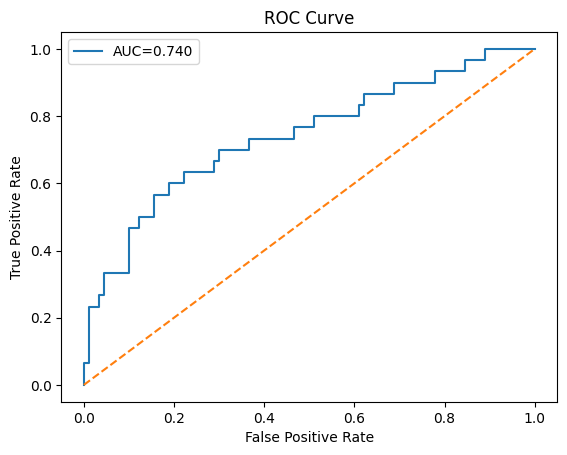

In [ ]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, p_test)
plt.plot(fpr, tpr, label=f"AUC={metrics_test['AUC']:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Conclusion

The proposed pipeline, combining stability selection, mRMR-lite, and an ElasticNet–SVM ensemble, achieved moderate performance with strong specificity but low sensitivity. While it underperforms compared to literature models, its strength lies in interpretability and conservative screening of safe compounds.